# 09 Annotation: 26 Donors

Assign broad and fine cell-type annotations to the 26-donor Harmony object. Keep the marker-evidence plots needed to audit the annotation, define a conservative high-confidence UMN-like population, visualise it on the global UMAP, and save annotated checkpoints for downstream notebooks.

## Setup

In [16]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

PROJECT_ROOT = Path("/nemo/lab/schreibera/home/users/wangj/FlowCytometry/c9_multiomics")
sys.path.append(str(PROJECT_ROOT / "src"))

FIGURES_DIR = PROJECT_ROOT / "results" / "09_annotation_26donors" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "09_annotation_26donors" / "tables"
UMN_FIGURE_DIR = FIGURES_DIR / "umn_search"
UMN_TABLE_DIR = TABLES_DIR / "umn_search"

HARMONY_PATH = PROJECT_ROOT / "data" / "processed" / "merged" / "adata_hm_after_harmony_26donors.h5ad"
FULL_ANNOTATION_PATH = PROJECT_ROOT / "data" / "processed" / "merged" / "adata_full_for_annotation_26donors.h5ad"
ANNOTATED_HARMONY_PATH = PROJECT_ROOT / "data" / "processed" / "merged" / "adata_hm_annotated_26donors.h5ad"
ANNOTATED_FULL_PATH = PROJECT_ROOT / "data" / "processed" / "merged" / "adata_full_annotated_26donors.h5ad"

SAMPLE_SHEET = PROJECT_ROOT / "data" / "metadata" / "samples.csv"
PER_SAMPLE_DIR = PROJECT_ROOT / "data" / "processed" / "per_sample"
SUBTYPE_MARKER_PATH = PROJECT_ROOT / "config" / "marker_dict_subtypes.xlsx"

for directory in [FIGURES_DIR, TABLES_DIR, UMN_FIGURE_DIR, UMN_TABLE_DIR, FULL_ANNOTATION_PATH.parent]:
    directory.mkdir(parents=True, exist_ok=True)

REBUILD_FULL_ANNOTATION_OBJECT = False
COUNTS_LAYER = "counts"
CLUSTER_COL = "leiden_harmony"
BROAD_COL = "cell_class_major_harmony"
SUBTYPE_COL = "cell_subtype"


## Load And Align Objects

In [17]:
adata_hm = sc.read_h5ad(HARMONY_PATH)
print(adata_hm)
print("Harmony cluster column present:", CLUSTER_COL in adata_hm.obs)


AnnData object with n_obs × n_vars = 167326 × 2000
    obs: 'sample', 'condition', 'dataset', 'tissue', 'source_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outliers', 'mt_outliers', 'high_quality_cells', 'soupx_clusters', 'doublet_score_scrublet', 'predicted_doublet_scrublet', 'concat_sample_id', 'leiden', 'leiden_harmony'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'highly_variable', 'mean', 'std'
    uns: 'condition_colors', 'leiden', 'leiden_colors', 'leiden_harmony', 'leiden_harmony_colors', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log1p_normalized_counts', 'normalized_counts', 'raw_counts', 'soupx

In [18]:
if FULL_ANNOTATION_PATH.exists() and not REBUILD_FULL_ANNOTATION_OBJECT:
    adata_full = sc.read_h5ad(FULL_ANNOTATION_PATH)
    print(f"Loaded full-gene annotation source: {FULL_ANNOTATION_PATH}")
else:
    samples = pd.read_csv(SAMPLE_SHEET)
    adatas = []

    for _, row in samples.iterrows():
        sample_id = str(row["sample_id"])
        matches = sorted((PER_SAMPLE_DIR / sample_id).glob("*_after_doublet_removal.h5ad"))
        if len(matches) != 1:
            raise FileNotFoundError(
                f"Expected one final per-sample object for {sample_id}, found {len(matches)}: {matches}"
            )

        ad = sc.read_h5ad(matches[0])
        for col in ["condition", "dataset", "tissue", "source_name"]:
            ad.obs[col] = row[col]
        ad.obs["sample"] = sample_id
        ad.obs["barcode"] = ad.obs_names.astype(str)
        ad.obs["merge_key"] = ad.obs["sample"].astype(str) + "__" + ad.obs["barcode"].astype(str)
        ad.obs_names = ad.obs["merge_key"].to_numpy()
        adatas.append(ad)

    adata_full = sc.concat(adatas, join="outer", merge="same", fill_value=0)
    adata_full.write_h5ad(FULL_ANNOTATION_PATH)
    print(f"Saved full-gene annotation source: {FULL_ANNOTATION_PATH}")

adata_full.obs_names_make_unique()

if "soupx_counts" in adata_full.layers:
    adata_full.layers[COUNTS_LAYER] = adata_full.layers["soupx_counts"].copy()
elif "raw_counts" in adata_full.layers:
    adata_full.layers[COUNTS_LAYER] = adata_full.layers["raw_counts"].copy()
else:
    adata_full.layers[COUNTS_LAYER] = adata_full.X.copy()

if not adata_hm.obs_names.astype(str).str.contains("__", regex=False).all():
    adata_hm.obs["barcode"] = adata_hm.obs_names.astype(str)
    adata_hm.obs["merge_key"] = adata_hm.obs["sample"].astype(str) + "__" + adata_hm.obs["barcode"].astype(str)
    adata_hm.obs_names = adata_hm.obs["merge_key"].to_numpy()

shared = adata_hm.obs_names.intersection(adata_full.obs_names)
adata_hm = adata_hm[shared].copy()
adata_full = adata_full[shared].copy()

if not adata_hm.obs_names.equals(adata_full.obs_names):
    raise ValueError("Harmony and full-gene objects are not aligned.")

adata_full.obs[CLUSTER_COL] = adata_hm.obs[CLUSTER_COL].to_numpy()
adata_full.obsm["X_umap"] = adata_hm.obsm["X_umap"].copy()
if "X_pca_harmony" in adata_hm.obsm:
    adata_full.obsm["X_pca_harmony"] = adata_hm.obsm["X_pca_harmony"].copy()

print("Number of nuclei/cells in current analysis:")
print(f"adata_hm:   {adata_hm.n_obs:,} cells x {adata_hm.n_vars:,} genes")
print(f"adata_full: {adata_full.n_obs:,} cells x {adata_full.n_vars:,} genes")

print("\nCells by condition:")
display(adata_hm.obs["condition"].astype(str).value_counts().sort_index().rename_axis("condition").reset_index(name="n_cells"))

print("\nCells by sample:")
display(adata_hm.obs["sample"].astype(str).value_counts().sort_index().rename_axis("sample").reset_index(name="n_cells"))


Loaded full-gene annotation source: /nemo/lab/schreibera/home/users/wangj/FlowCytometry/c9_multiomics/data/processed/merged/adata_full_for_annotation_26donors.h5ad
Number of nuclei/cells in current analysis:
adata_hm:   163,784 cells x 2,000 genes
adata_full: 163,784 cells x 61,552 genes

Cells by condition:


,condition,n_cells
0,Control,41994
1,c9ALS,42267
2,sALS,79523



Cells by sample:


,sample,n_cells
0,GSM5292143,8442
1,GSM5292144,12112
2,GSM5292145,5068
3,GSM5292146,8646
4,GSM5292147,10183
5,GSM5292148,9202
6,GSM5292149,11708
7,GSM5292150,10370
8,GSM5292151,8378
9,GSM5292152,3492


## Marker Plot Helpers

In [19]:
def marker_plot_object(adata, marker_dict):
    marker_dict = {
        label: [gene for gene in genes if gene in adata.var_names]
        for label, genes in marker_dict.items()
    }
    marker_dict = {label: genes for label, genes in marker_dict.items() if genes}
    genes = list(dict.fromkeys(gene for genes in marker_dict.values() for gene in genes))

    ad = adata[:, genes].copy()
    ad.X = ad.layers[COUNTS_LAYER].copy() if COUNTS_LAYER in ad.layers else ad.X.copy()
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)
    return ad, marker_dict


def load_subtype_markers(path):
    df = pd.read_excel(path)
    return {
        col.strip(): [str(gene).strip() for gene in df[col].dropna() if str(gene).strip()]
        for col in df.columns
    }


def lineage_from_subtype(subtype):
    if subtype.startswith("Ex."):
        return "Excitatory"
    if subtype.startswith("In."):
        return "Inhibitory"
    if subtype.startswith("Glia."):
        return "Glia"
    if subtype.startswith("Vasc."):
        return "Vascular"
    return None


## Broad Marker Evidence

/nemo/lab/schreibera/home/users/wangj/.conda/envs/c9_multiomics_py311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


Broad marker genes present:


Excitatory    13
Inhibitory     8
Glia          13
Vascular      13
Name: n_present, dtype: int64

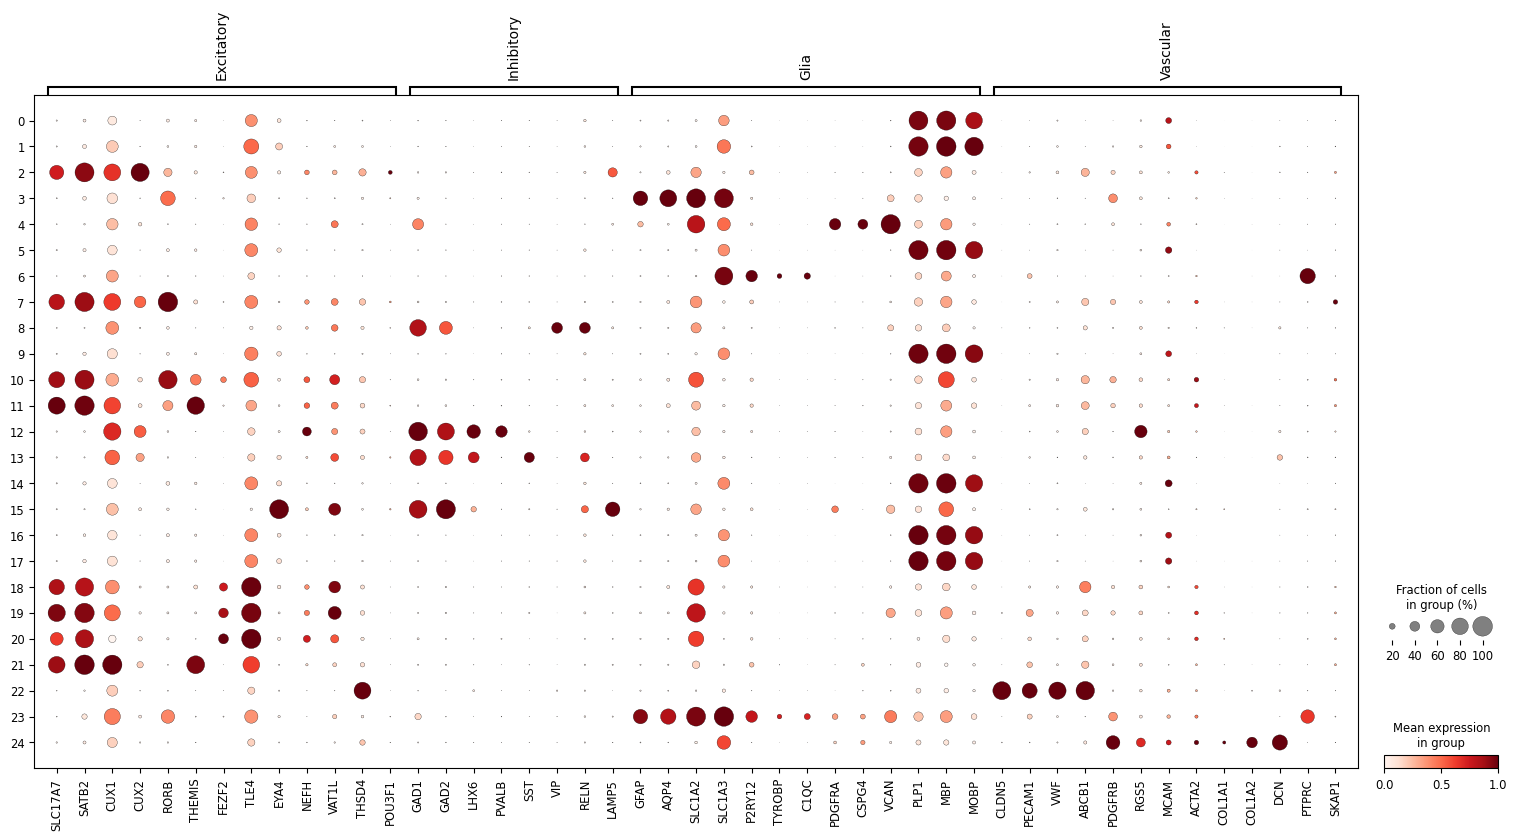

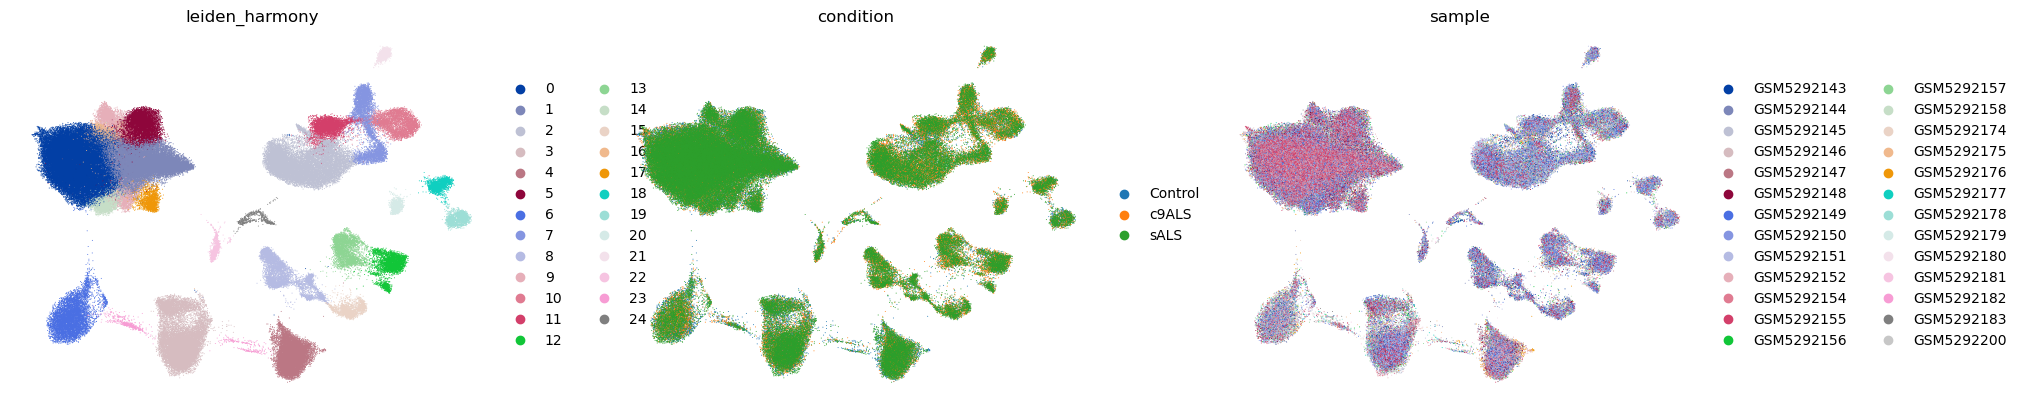

In [20]:
broad_markers = {
    "Excitatory": ["SLC17A7", "SATB2", "CUX1", "CUX2", "RORB", "THEMIS", "FEZF2", "TLE4", "EYA4", "NEFH", "VAT1L", "THSD4", "POU3F1"],
    "Inhibitory": ["GAD1", "GAD2", "LHX6", "PVALB", "SST", "VIP", "RELN", "LAMP5"],
    "Glia": ["GFAP", "AQP4", "SLC1A2", "SLC1A3", "P2RY12", "TYROBP", "C1QC", "PDGFRA", "CSPG4", "VCAN", "PLP1", "MBP", "MOBP"],
    "Vascular": ["CLDN5", "PECAM1", "VWF", "ABCB1", "PDGFRB", "RGS5", "MCAM", "ACTA2", "COL1A1", "COL1A2", "DCN", "PTPRC", "SKAP1"],
}

adata_broad_markers, broad_markers_present = marker_plot_object(adata_full, broad_markers)
print("Broad marker genes present:")
display(pd.Series({label: len(genes) for label, genes in broad_markers_present.items()}, name="n_present"))

sc.pl.dotplot(
    adata_broad_markers,
    broad_markers_present,
    groupby=CLUSTER_COL,
    standard_scale="var",
)

sc.pl.umap(
    adata_broad_markers,
    color=[CLUSTER_COL, "condition", "sample"],
    ncols=3,
    size=2,
    frameon=False,
)


## Broad Class Assignment

Broad class counts:


cell_class_major_harmony
Glia          117152
Excitatory     32043
Inhibitory     13197
Vascular        1392
Name: count, dtype: int64

Broad class by condition:


condition,Control,c9ALS,sALS
cell_class_major_harmony,,,
Excitatory,6742,12112,13189
Inhibitory,2426,4831,5940
Glia,32522,24912,59718
Vascular,304,412,676


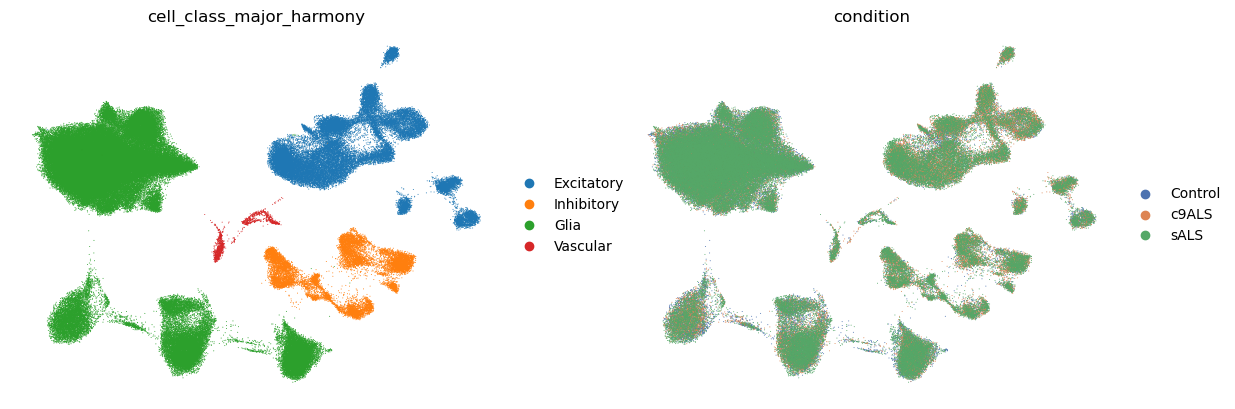

In [21]:
cluster_to_major = {
    "0":  "Glia",
    "1":  "Glia",
    "2":  "Excitatory",
    "3":  "Glia",
    "4":  "Glia",
    "5":  "Glia",
    "6":  "Glia",
    "7":  "Excitatory",
    "8":  "Inhibitory",
    "9":  "Glia",
    "10": "Excitatory",
    "11": "Excitatory",
    "12": "Inhibitory",
    "13": "Inhibitory",
    "14": "Glia",
    "15": "Inhibitory",
    "16": "Glia",
    "17": "Glia",
    "18": "Excitatory",
    "19": "Excitatory",
    "20": "Excitatory",
    "21": "Excitatory",
    "22": "Vascular",
    "23": "Glia",
    "24": "Vascular",
}

adata_hm.obs[BROAD_COL] = adata_hm.obs[CLUSTER_COL].astype(str).map(cluster_to_major)
adata_hm.obs[BROAD_COL] = pd.Categorical(
    adata_hm.obs[BROAD_COL],
    categories=["Excitatory", "Inhibitory", "Glia", "Vascular"],
)
adata_full.obs[BROAD_COL] = adata_hm.obs[BROAD_COL].copy()

print("Broad class counts:")
display(adata_hm.obs[BROAD_COL].value_counts(dropna=False))

print("Broad class by condition:")
display(pd.crosstab(adata_hm.obs[BROAD_COL], adata_hm.obs["condition"]))

sc.pl.umap(
    adata_hm,
    color=[BROAD_COL, "condition"],
    ncols=2,
    size=2,
    frameon=False,
)


## Subtype Marker Evidence

In [ ]:
subtype_markers = load_subtype_markers(SUBTYPE_MARKER_PATH)
subtype_markers_by_lineage = {"Excitatory": {}, "Inhibitory": {}, "Glia": {}, "Vascular": {}}

for subtype, genes in subtype_markers.items():
    lineage = lineage_from_subtype(subtype)
    if lineage:
        subtype_markers_by_lineage[lineage][subtype] = genes

print("Subtype marker panels:")
display(pd.Series({lineage: len(marker_dict) for lineage, marker_dict in subtype_markers_by_lineage.items()}, name="n_panels"))

for lineage, marker_dict in subtype_markers_by_lineage.items():
    lineage_mask = adata_full.obs[BROAD_COL].astype(str).eq(lineage)
    if lineage_mask.sum() == 0:
        continue

    adata_lineage, markers_present = marker_plot_object(adata_full[lineage_mask].copy(), marker_dict)
    if not markers_present:
        print(f"No subtype markers present for {lineage}; skipped.")
        continue

    print(f"{lineage} subtype marker evidence")
    sc.pl.dotplot(
        adata_lineage,
        markers_present,
        groupby=CLUSTER_COL,
        standard_scale="var",
    )


## Fine Subtype Assignment

Fine subtype counts:


cell_subtype
Glia.Oligo                 87096
Ex.L2_L3.CUX2_RASGRF2      14924
Glia.Astro.GFAP.neg        14239
Glia.OPC                    9120
Glia.Micro                  6697
Ex.L4_L5.RORB_POU3F2        4945
In.5HT3aR.DISC1_RELN        4798
Ex.L4_L6.RORB_LRRK1         3671
Ex.L5_L6.THEMIS_TMEM233     3660
In.PV.PVALB_MYBPC1          3379
In.SOM.SST_ADAMTS19         3191
In.Rosehip.LAMP5_PMEPA1     1829
Ex.L6.TLE4_MEGF11           1651
Ex.L6.TLE4_CCBE1            1480
Ex.L5.PCP4_NXPH2             872
Ex.L5_L6.THEMIS_NR4A2        840
Vasc.Endo.Venous             782
Vasc.Mural.Pericyte          610
Name: count, dtype: int64

Subtype by broad class:


cell_subtype,Ex.L2_L3.CUX2_RASGRF2,Ex.L4_L5.RORB_POU3F2,Ex.L4_L6.RORB_LRRK1,Ex.L5.PCP4_NXPH2,Ex.L5_L6.THEMIS_NR4A2,Ex.L5_L6.THEMIS_TMEM233,Ex.L6.TLE4_CCBE1,Ex.L6.TLE4_MEGF11,Glia.Astro.GFAP.neg,Glia.Micro,Glia.OPC,Glia.Oligo,In.5HT3aR.DISC1_RELN,In.PV.PVALB_MYBPC1,In.Rosehip.LAMP5_PMEPA1,In.SOM.SST_ADAMTS19,Vasc.Endo.Venous,Vasc.Mural.Pericyte
cell_class_major_harmony,,,,,,,,,,,,,,,,,,
Excitatory,14924,4945,3671,872,840,3660,1480,1651,0,0,0,0,0,0,0,0,0,0
Inhibitory,0,0,0,0,0,0,0,0,0,0,0,0,4798,3379,1829,3191,0,0
Glia,0,0,0,0,0,0,0,0,14239,6697,9120,87096,0,0,0,0,0,0
Vascular,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,782,610


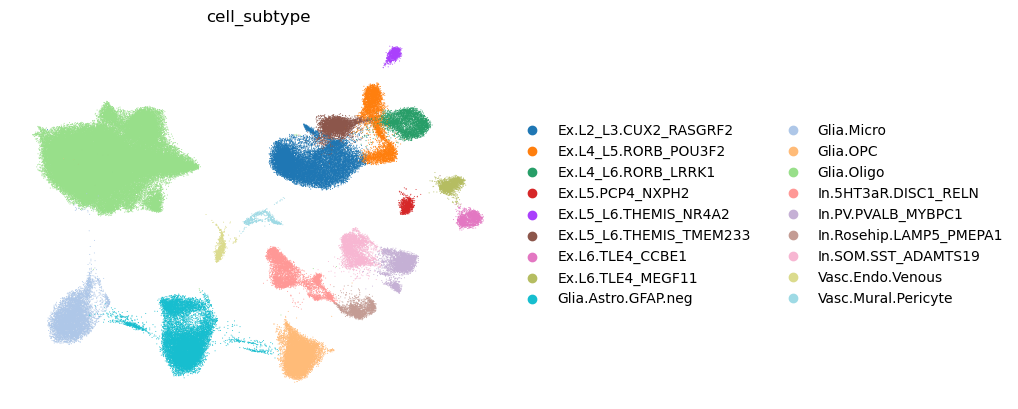

In [22]:
cluster_to_exc_subtype = {
    "2":  "Ex.L2_L3.CUX2_RASGRF2",
    "7":  "Ex.L4_L5.RORB_POU3F2",
    "10": "Ex.L4_L6.RORB_LRRK1",
    "11": "Ex.L5_L6.THEMIS_TMEM233",
    "18": "Ex.L6.TLE4_MEGF11",
    "19": "Ex.L6.TLE4_CCBE1",
    "20": "Ex.L5.PCP4_NXPH2",
    "21": "Ex.L5_L6.THEMIS_NR4A2",
}

cluster_to_inh_subtype = {
    "8":  "In.5HT3aR.DISC1_RELN",
    "12": "In.PV.PVALB_MYBPC1",
    "13": "In.SOM.SST_ADAMTS19",
    "15": "In.Rosehip.LAMP5_PMEPA1",
}

cluster_to_glia_subtype = {
    "0":  "Glia.Oligo",
    "1":  "Glia.Oligo",
    "3":  "Glia.Astro.GFAP.neg",
    "4":  "Glia.OPC",
    "5":  "Glia.Oligo",
    "6":  "Glia.Micro",
    "9":  "Glia.Oligo",
    "14": "Glia.Oligo",
    "16": "Glia.Oligo",
    "17": "Glia.Oligo",
    "23": "Glia.Astro.GFAP.neg",
}

cluster_to_vasc_subtype = {
    "22": "Vasc.Endo.Venous",
    "24": "Vasc.Mural.Pericyte",
}

subtype = pd.Series(pd.NA, index=adata_hm.obs_names, dtype="object")
for broad_class, mapping in [
    ("Excitatory", cluster_to_exc_subtype),
    ("Inhibitory", cluster_to_inh_subtype),
    ("Glia", cluster_to_glia_subtype),
    ("Vascular", cluster_to_vasc_subtype),
]:
    mask = adata_hm.obs[BROAD_COL].astype(str).eq(broad_class)
    subtype.loc[mask] = adata_hm.obs.loc[mask, CLUSTER_COL].astype(str).map(mapping)

adata_hm.obs[SUBTYPE_COL] = subtype.astype("category")
adata_full.obs[SUBTYPE_COL] = adata_hm.obs[SUBTYPE_COL].copy()

print("Fine subtype counts:")
display(adata_hm.obs[SUBTYPE_COL].value_counts(dropna=False))

print("Subtype by broad class:")
display(pd.crosstab(adata_hm.obs[BROAD_COL], adata_hm.obs[SUBTYPE_COL]))

sc.pl.umap(
    adata_hm,
    color=[SUBTYPE_COL],
    size=2,
    frameon=False,
)


## UMN-Like Marker Evidence

UMN markers present: ['VAT1L', 'EYA4', 'THSD4', 'POU3F1', 'FEZF2', 'BCL11B', 'PCP4', 'TLE4']
UMN markers missing: []


/nemo/lab/schreibera/home/users/wangj/.conda/envs/c9_multiomics_py311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


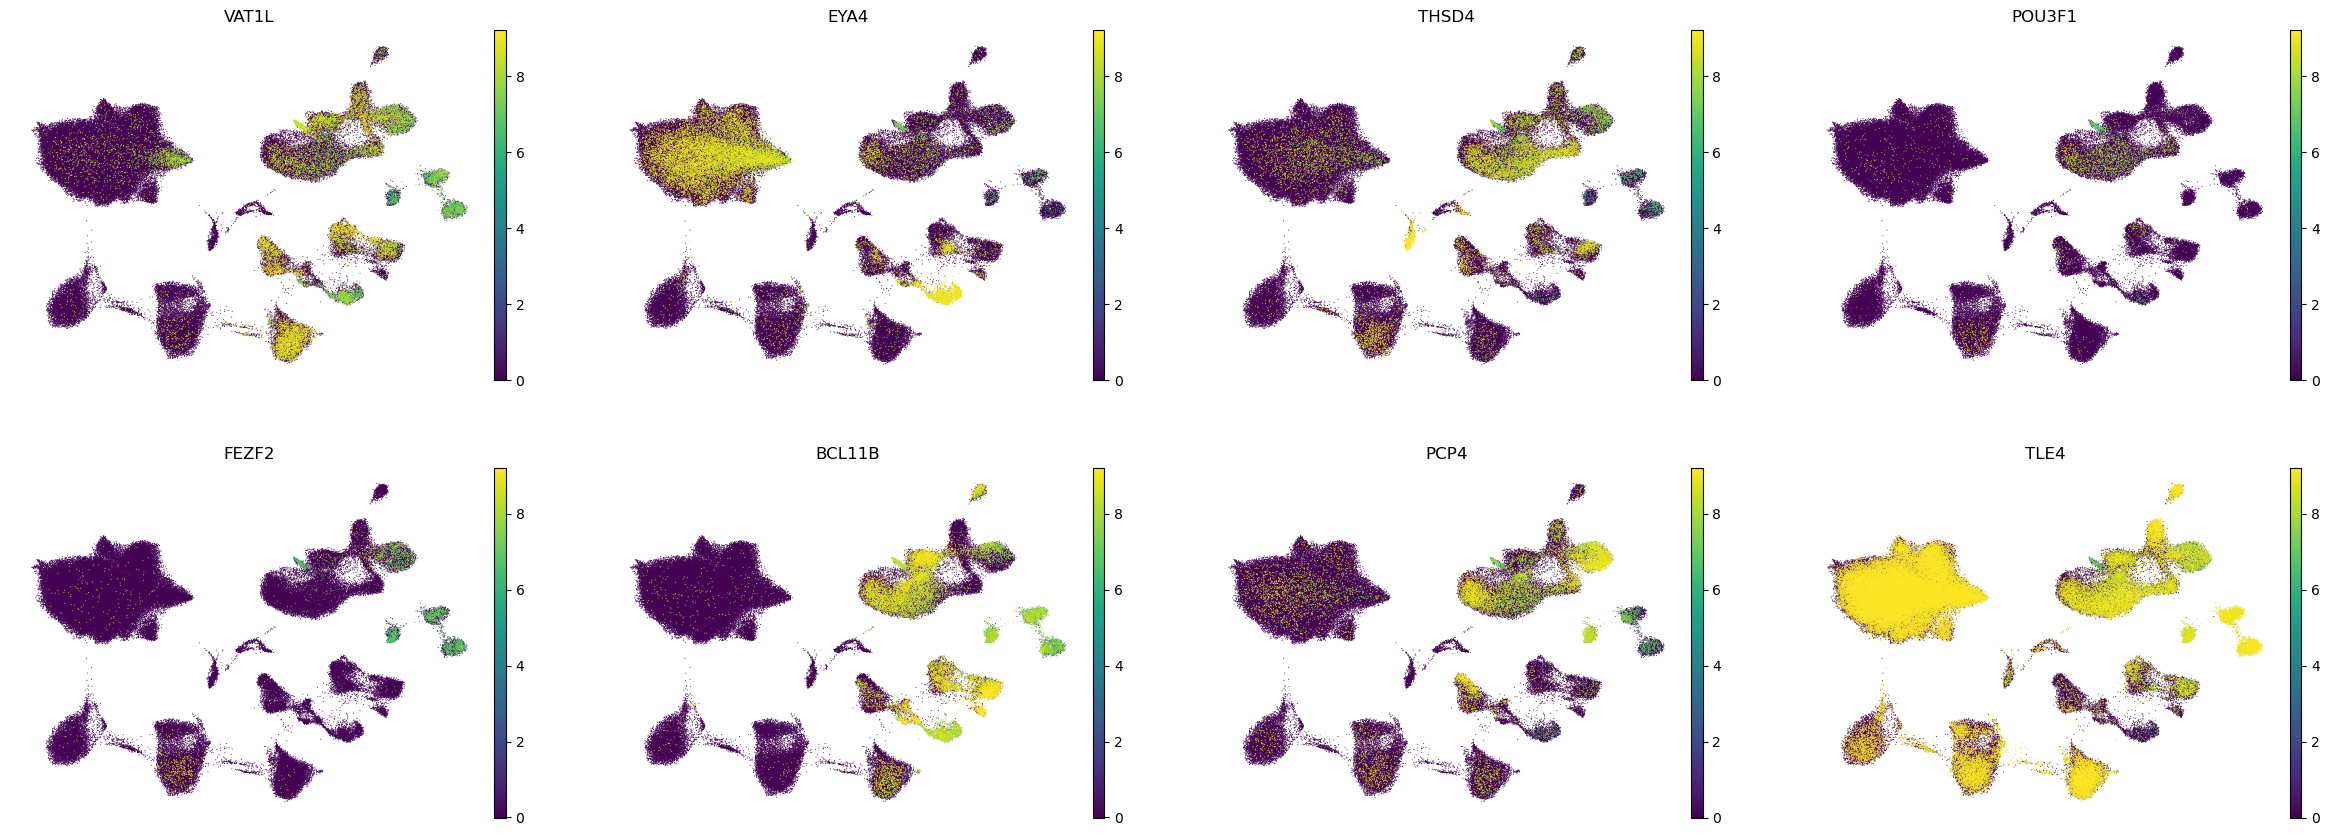

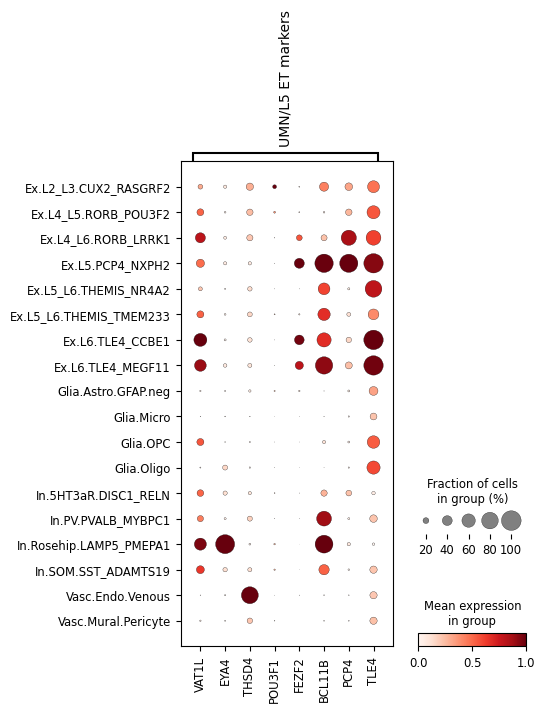

In [23]:
UMN_MARKERS = ["VAT1L", "EYA4", "THSD4", "POU3F1", "FEZF2", "BCL11B", "PCP4", "TLE4"]
UMN_MARKERS_PRESENT = [gene for gene in UMN_MARKERS if gene in adata_full.var_names]
UMN_MARKERS_MISSING = [gene for gene in UMN_MARKERS if gene not in adata_full.var_names]

print("UMN markers present:", UMN_MARKERS_PRESENT)
print("UMN markers missing:", UMN_MARKERS_MISSING)

adata_umn_markers = adata_full[:, UMN_MARKERS_PRESENT].copy()
adata_umn_markers.X = adata_umn_markers.layers[COUNTS_LAYER].copy() if COUNTS_LAYER in adata_umn_markers.layers else adata_umn_markers.X.copy()
sc.pp.normalize_total(adata_umn_markers, target_sum=1e4)
sc.pp.log1p(adata_umn_markers)

sc.pl.umap(
    adata_umn_markers,
    color=UMN_MARKERS_PRESENT,
    ncols=4,
    size=2,
    frameon=False,
    cmap="viridis",
)

umn_marker_panel = {"UMN/L5 ET markers": UMN_MARKERS_PRESENT}
sc.pl.dotplot(
    adata_umn_markers,
    umn_marker_panel,
    groupby=SUBTYPE_COL,
    standard_scale="var",
)


## Conservative UMN-Like Annotation

In [24]:
layer_to_use = COUNTS_LAYER if COUNTS_LAYER in adata_full.layers else None
expr = {}

for gene in UMN_MARKERS_PRESENT:
    x = adata_full[:, gene].layers[layer_to_use] if layer_to_use is not None else adata_full[:, gene].X
    expr[gene] = x.toarray().ravel() if hasattr(x, "toarray") else np.asarray(x).ravel()

expr = pd.DataFrame(expr, index=adata_full.obs_names)
detected = expr > 0

adata_full.obs["UMN_strict_detected"] = (
    detected.get("VAT1L", False)
    & (detected.get("EYA4", False) | detected.get("THSD4", False))
    & (detected.get("BCL11B", False) | detected.get("FEZF2", False) | detected.get("PCP4", False))
)

adata_full.obs["UMN_like_high_confidence"] = (
    adata_full.obs[SUBTYPE_COL].astype(str).eq("Ex.L5.PCP4_NXPH2")
    & adata_full.obs["UMN_strict_detected"].astype(bool)
)

adata_full.obs["cell_subtype_with_UMN_like"] = adata_full.obs[SUBTYPE_COL].astype(str)
adata_full.obs.loc[
    adata_full.obs["UMN_like_high_confidence"],
    "cell_subtype_with_UMN_like",
] = "Ex.L5.PCP4_NXPH2.UMN_like"

umn_summary = (
    adata_full.obs
    .groupby(SUBTYPE_COL)["UMN_like_high_confidence"]
    .agg(n_cells="size", n_umn_like="sum", pct_umn_like="mean")
)
umn_summary["pct_umn_like"] *= 100

display(umn_summary.sort_values("n_umn_like", ascending=False).head(15))


/tmp/slurm_48994769/ipykernel_1182397/3270031240.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(SUBTYPE_COL)["UMN_like_high_confidence"]


,n_cells,n_umn_like,pct_umn_like
cell_subtype,,,
Ex.L5.PCP4_NXPH2,872,65,7.454128
Ex.L2_L3.CUX2_RASGRF2,14924,0,0.000000
Ex.L4_L5.RORB_POU3F2,4945,0,0.000000
Ex.L4_L6.RORB_LRRK1,3671,0,0.000000
Ex.L5_L6.THEMIS_NR4A2,840,0,0.000000
Ex.L5_L6.THEMIS_TMEM233,3660,0,0.000000
Ex.L6.TLE4_CCBE1,1480,0,0.000000
Ex.L6.TLE4_MEGF11,1651,0,0.000000
Glia.Astro.GFAP.neg,14239,0,0.000000


In [25]:
common_cells = adata_hm.obs_names.intersection(adata_full.obs_names)

adata_hm.obs["UMN_strict_detected"] = False
adata_hm.obs.loc[common_cells, "UMN_strict_detected"] = (
    adata_full.obs.loc[common_cells, "UMN_strict_detected"].astype(bool).values
)

adata_hm.obs["UMN_like_high_confidence"] = False
adata_hm.obs.loc[common_cells, "UMN_like_high_confidence"] = (
    adata_full.obs.loc[common_cells, "UMN_like_high_confidence"].astype(bool).values
)

adata_hm.obs["cell_subtype_with_UMN_like"] = adata_hm.obs[SUBTYPE_COL].astype(str)
adata_hm.obs.loc[common_cells, "cell_subtype_with_UMN_like"] = (
    adata_full.obs.loc[common_cells, "cell_subtype_with_UMN_like"].astype(str).values
)

print("High-confidence UMN-like cells:", int(adata_hm.obs["UMN_like_high_confidence"].sum()))


High-confidence UMN-like cells: 65


## UMN-Like Presentation Figures

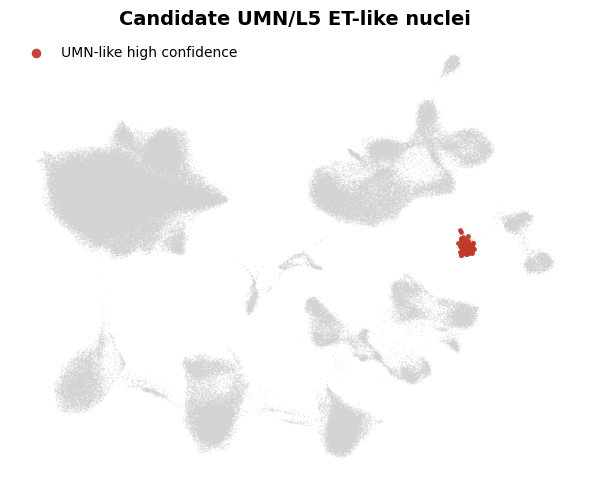

In [26]:
umap = adata_hm.obsm["X_umap"]
umn_mask = adata_hm.obs["UMN_like_high_confidence"].astype(bool).to_numpy()

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(umap[:, 0], umap[:, 1], s=1, c="lightgrey", alpha=0.35, linewidths=0, rasterized=True)
ax.scatter(
    umap[umn_mask, 0],
    umap[umn_mask, 1],
    s=12,
    c="#c0392b",
    alpha=0.95,
    linewidths=0,
    rasterized=True,
    label="UMN-like high confidence",
)
ax.set_title("Candidate UMN/L5 ET-like nuclei", fontsize=14, weight="bold")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(frameon=False, loc="best", markerscale=2)
plt.tight_layout()
plt.show()


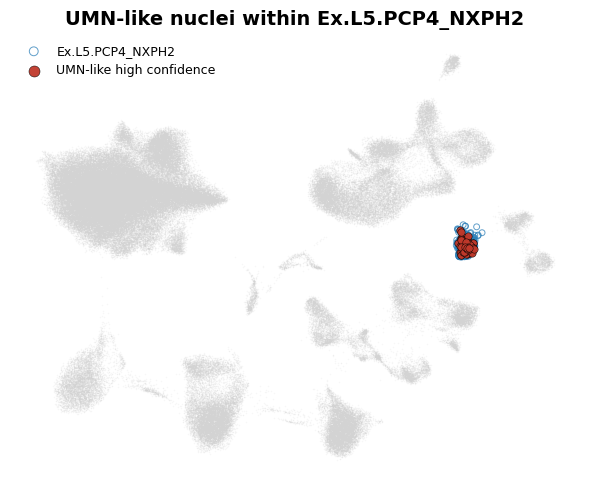

In [27]:
pcp4_mask = adata_hm.obs[SUBTYPE_COL].astype(str).eq("Ex.L5.PCP4_NXPH2").to_numpy()
umn_mask = adata_hm.obs["UMN_like_high_confidence"].astype(bool).to_numpy()

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(umap[:, 0], umap[:, 1], s=1, c="lightgrey", alpha=0.18, linewidths=0, rasterized=True)
ax.scatter(
    umap[pcp4_mask, 0],
    umap[pcp4_mask, 1],
    s=18,
    facecolors="none",
    edgecolors="#2c7fb8",
    alpha=0.75,
    linewidths=0.7,
    rasterized=True,
    label="Ex.L5.PCP4_NXPH2",
)
ax.scatter(
    umap[umn_mask, 0],
    umap[umn_mask, 1],
    s=28,
    c="#c0392b",
    edgecolors="black",
    alpha=0.95,
    linewidths=0.35,
    rasterized=True,
    label="UMN-like high confidence",
)
ax.set_title("UMN-like nuclei within Ex.L5.PCP4_NXPH2", fontsize=14, weight="bold")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(frameon=False, loc="best", markerscale=1.5, fontsize=9)
plt.tight_layout()
plt.show()


/nemo/lab/schreibera/home/users/wangj/.conda/envs/c9_multiomics_py311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


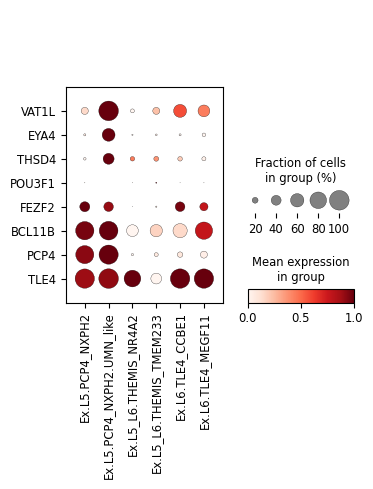

In [28]:
UMN_DISPLAY_LABEL = "Ex.L5.PCP4_NXPH2.UMN_like"
UMN_MARKERS_TO_SHOW = [gene for gene in UMN_MARKERS if gene in adata_full.var_names]
GROUPS_TO_SHOW = [
    "Ex.L5.PCP4_NXPH2",
    UMN_DISPLAY_LABEL,
    "Ex.L5_L6.THEMIS_NR4A2",
    "Ex.L5_L6.THEMIS_TMEM233",
    "Ex.L6.TLE4_CCBE1",
    "Ex.L6.TLE4_MEGF11",
]

adata_umn_evidence = adata_full[
    adata_full.obs["cell_subtype_with_UMN_like"].astype(str).isin(GROUPS_TO_SHOW),
    UMN_MARKERS_TO_SHOW,
].copy()
adata_umn_evidence.X = adata_umn_evidence.layers[COUNTS_LAYER].copy() if COUNTS_LAYER in adata_umn_evidence.layers else adata_umn_evidence.X.copy()
sc.pp.normalize_total(adata_umn_evidence, target_sum=1e4)
sc.pp.log1p(adata_umn_evidence)
adata_umn_evidence.obs["plot_group"] = pd.Categorical(
    adata_umn_evidence.obs["cell_subtype_with_UMN_like"].astype(str),
    categories=GROUPS_TO_SHOW,
    ordered=True,
)

sc.pl.dotplot(
    adata_umn_evidence,
    var_names=UMN_MARKERS_TO_SHOW,
    groupby="plot_group",
    standard_scale="var",
    swap_axes=True,
)


In [40]:
umn_obs = adata_full.obs[
    adata_full.obs["UMN_like_high_confidence"].astype(bool)
].copy()

umn_condition_table = (
    umn_obs
    .groupby("condition")
    .agg(
        **{
            "UMN-like nuclei": ("condition", "size"),
            "Donors represented": ("sample", "nunique"),
        }
    )
    .reindex(["Control", "sALS", "c9ALS"])
    .fillna(0)
    .astype(int)
)

display(umn_condition_table)

print("Total high-confidence UMN-like nuclei:", int(umn_obs.shape[0]))

/tmp/slurm_48994769/ipykernel_1182397/195360075.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("condition")


,UMN-like nuclei,Donors represented
condition,,
Control,28,8
sALS,9,7
c9ALS,28,5


Total high-confidence UMN-like nuclei: 65


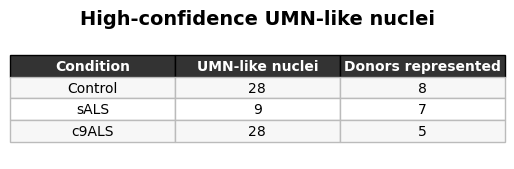

In [42]:
table_df = umn_condition_table.reset_index().rename(
    columns={"condition": "Condition"}
)

fig, ax = plt.subplots(figsize=(5.2, 1.8))
ax.axis("off")

table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.5)

# Header styling
for col in range(len(table_df.columns)):
    cell = table[(0, col)]
    cell.set_text_props(weight="bold", color="white")
    cell.set_facecolor("#333333")

# Body styling
for row in range(1, len(table_df) + 1):
    for col in range(len(table_df.columns)):
        cell = table[(row, col)]
        cell.set_edgecolor("#bbbbbb")
        cell.set_facecolor("#f7f7f7" if row % 2 else "white")

ax.set_title(
    "High-confidence UMN-like nuclei",
    fontsize=14,
    weight="bold",
    pad=10,
)

plt.tight_layout()
plt.show()

## Optional Paper-Style Broad-Class UMAPs

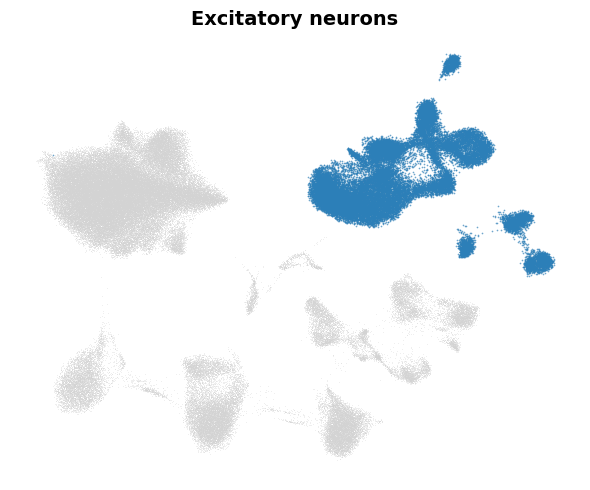

Saved: /nemo/lab/schreibera/home/users/wangj/FlowCytometry/c9_multiomics/results/09_annotation_26donors/figures/09_excitatory_neurons_subtype_umap_paper_style_no_overlap.png


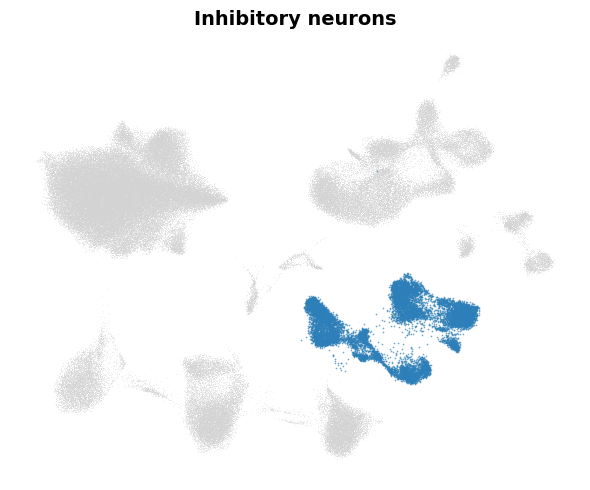

Saved: /nemo/lab/schreibera/home/users/wangj/FlowCytometry/c9_multiomics/results/09_annotation_26donors/figures/09_inhibitory_neurons_subtype_umap_paper_style_no_overlap.png


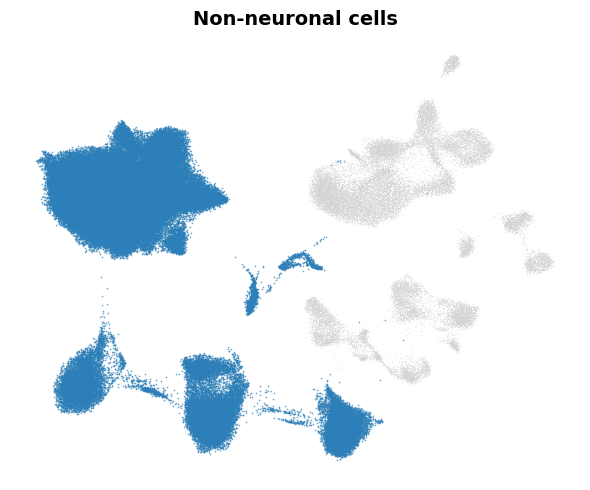

Saved: /nemo/lab/schreibera/home/users/wangj/FlowCytometry/c9_multiomics/results/09_annotation_26donors/figures/09_non_neuronal_cells_subtype_umap_paper_style_no_overlap.png


In [30]:
def broad_group_masks(adata, broad_col=BROAD_COL, subtype_col=SUBTYPE_COL):
    broad = adata.obs[broad_col].astype(str)
    subtype = adata.obs[subtype_col].astype(str)
    combined = (broad + " " + subtype).str.lower()
    excitatory = combined.str.contains("excitatory", na=False) | combined.str.contains(r"\bex[._ ]", regex=True, na=False)
    inhibitory = combined.str.contains("inhibitory", na=False) | combined.str.contains(r"\bin[._ ]", regex=True, na=False)
    non_neuronal = ~(excitatory | inhibitory)
    return {
        "Excitatory neurons": excitatory.to_numpy(),
        "Inhibitory neurons": inhibitory.to_numpy(),
        "Non-neuronal cells": non_neuronal.to_numpy(),
    }


def plot_simple_broad_umap(adata, mask, title):
    coords = adata.obsm["X_umap"]
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(coords[:, 0], coords[:, 1], s=0.5, c="lightgrey", alpha=0.25, linewidths=0, rasterized=True)
    ax.scatter(coords[mask, 0], coords[mask, 1], s=1.5, c="#2c7fb8", alpha=0.65, linewidths=0, rasterized=True)
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    return fig

broad_masks = broad_group_masks(adata_hm)
for title, mask in broad_masks.items():
    fig = plot_simple_broad_umap(adata_hm, mask, title)
    filename = title.lower().replace(" ", "_").replace("-", "_")
    out_png = FIGURES_DIR / f"09_{filename}_subtype_umap_paper_style_no_overlap.png"
    fig.savefig(out_png, dpi=600, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", out_png)


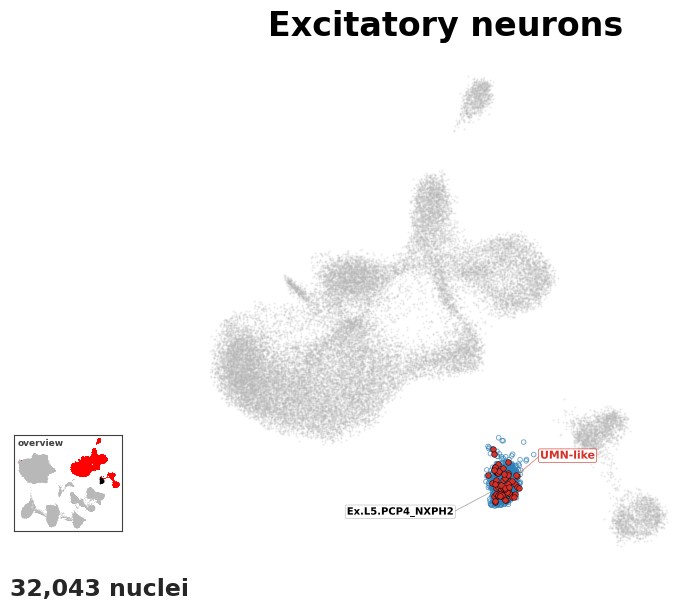

Saved: /nemo/lab/schreibera/home/users/wangj/FlowCytometry/c9_multiomics/results/09_annotation_26donors/figures/09_excitatory_neurons_pcp4_umn_like_overlap_paper_style_no_overlap.png


In [39]:
import matplotlib.pyplot as plt
from matplotlib import patheffects
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Self-contained paper-style excitatory UMAP:
# Ex.L5.PCP4_NXPH2 parent population + UMN-like high-confidence subset
# ---------------------------------------------------------------------

UMAP_KEY = "X_umap"
POINT_SIZE = 2.0
OVERVIEW_POINT_SIZE = 0.22

title = "Excitatory neurons"
filename = "excitatory_neurons_pcp4_umn_like_overlap"

coords = pd.DataFrame(
    adata_hm.obsm[UMAP_KEY],
    columns=["UMAP1", "UMAP2"],
    index=adata_hm.obs_names,
)

# Masks.
exc_mask = (
    adata_hm.obs[BROAD_COL].astype(str)
    .eq("Excitatory")
    .to_numpy()
)

pcp4_mask = (
    adata_hm.obs[SUBTYPE_COL].astype(str)
    .eq("Ex.L5.PCP4_NXPH2")
    .to_numpy()
)

umn_mask = (
    adata_hm.obs["UMN_like_high_confidence"]
    .astype(bool)
    .to_numpy()
)

# Safety checks.
if exc_mask.sum() == 0:
    raise ValueError("No excitatory cells found.")

if pcp4_mask.sum() == 0:
    print("Warning: no Ex.L5.PCP4_NXPH2 cells found.")

if umn_mask.sum() == 0:
    print("Warning: no UMN_like_high_confidence cells found.")

# Global UMAP limits for inset.
x_min, x_max = coords["UMAP1"].min(), coords["UMAP1"].max()
y_min, y_max = coords["UMAP2"].min(), coords["UMAP2"].max()

x_pad = 0.03 * (x_max - x_min)
y_pad = 0.03 * (y_max - y_min)

global_xlim = (x_min - x_pad, x_max + x_pad)
global_ylim = (y_min - y_pad, y_max + y_pad)

# Robust excitatory zoom limits.
plot_df = coords.loc[exc_mask].copy()

x_low, x_high = plot_df["UMAP1"].quantile([0.005, 0.995])
y_low, y_high = plot_df["UMAP2"].quantile([0.005, 0.995])

x_span = x_high - x_low
y_span = y_high - y_low

subset_xlim = (x_low - 0.08 * x_span, x_high + 0.08 * x_span)
subset_ylim = (y_low - 0.08 * y_span, y_high + 0.08 * y_span)

n_cells = int(exc_mask.sum())

# Figure layout copied from the paper-style broad-class UMAP.
fig = plt.figure(figsize=(8.0, 6.6))

ax = fig.add_axes([0.22, 0.12, 0.74, 0.78])
overview_ax = fig.add_axes(
    [0.055, 0.175, 0.145, 0.145],
    facecolor="white",
    zorder=30,
)

fig.suptitle(
    title,
    fontsize=24,
    weight="bold",
    x=0.60,
    y=0.965,
)

# Background: all excitatory neurons.
ax.scatter(
    coords.loc[exc_mask, "UMAP1"],
    coords.loc[exc_mask, "UMAP2"],
    s=POINT_SIZE,
    color="0.72",
    linewidths=0,
    alpha=0.30,
    rasterized=True,
    zorder=1,
)

# Parent subtype: Ex.L5.PCP4_NXPH2, open blue circles.
ax.scatter(
    coords.loc[pcp4_mask, "UMAP1"],
    coords.loc[pcp4_mask, "UMAP2"],
    s=POINT_SIZE * 5.5,
    facecolors="none",
    edgecolors="#2c7fb8",
    linewidths=0.55,
    alpha=0.80,
    rasterized=True,
    zorder=5,
    label="Ex.L5.PCP4_NXPH2",
)

# UMN-like subset: red filled circles on top.
ax.scatter(
    coords.loc[umn_mask, "UMAP1"],
    coords.loc[umn_mask, "UMAP2"],
    s=POINT_SIZE * 8.0,
    color="#d73027",
    edgecolors="black",
    linewidths=0.35,
    alpha=0.98,
    rasterized=True,
    zorder=10,
    label="UMN-like high confidence",
)

# Label parent subtype.
if pcp4_mask.sum() > 0:
    pcp4_x = coords.loc[pcp4_mask, "UMAP1"].median()
    pcp4_y = coords.loc[pcp4_mask, "UMAP2"].median()

    pcp4_label_x = pcp4_x - 0.115 * x_span
    pcp4_label_y = pcp4_y - 0.060 * y_span

    ax.plot(
        [pcp4_x, pcp4_label_x],
        [pcp4_y, pcp4_label_y],
        color="0.35",
        linewidth=0.55,
        alpha=0.55,
        zorder=18,
    )

    ax.text(
        pcp4_label_x,
        pcp4_label_y,
        "Ex.L5.PCP4_NXPH2",
        fontsize=7.2,
        ha="right",
        va="center",
        weight="bold",
        zorder=20,
        bbox=dict(
            boxstyle="round,pad=0.16",
            facecolor="white",
            edgecolor="0.65",
            linewidth=0.35,
            alpha=0.90,
        ),
        path_effects=[
            patheffects.withStroke(linewidth=0.9, foreground="white")
        ],
    )


# Label UMN-like subset.
if umn_mask.sum() > 0:
    umn_x = coords.loc[umn_mask, "UMAP1"].median()
    umn_y = coords.loc[umn_mask, "UMAP2"].median()

    umn_label_x = umn_x + 0.085 * x_span
    umn_label_y = umn_y + 0.070 * y_span

    ax.plot(
        [umn_x, umn_label_x],
        [umn_y, umn_label_y],
        color="#d73027",
        linewidth=0.55,
        alpha=0.65,
        zorder=23,
    )

    ax.text(
        umn_label_x,
        umn_label_y,
        "UMN-like",
        fontsize=7.8,
        ha="left",
        va="center",
        weight="bold",
        color="#d73027",
        zorder=25,
        bbox=dict(
            boxstyle="round,pad=0.16",
            facecolor="white",
            edgecolor="#d73027",
            linewidth=0.45,
            alpha=0.94,
        ),
        path_effects=[
            patheffects.withStroke(linewidth=0.9, foreground="white")
        ],
    )

# Overview inset: all cells grey, excitatory red, UMN-like black.
overview_ax.scatter(
    coords["UMAP1"],
    coords["UMAP2"],
    s=OVERVIEW_POINT_SIZE,
    color="0.72",
    linewidths=0,
    alpha=0.55,
    rasterized=True,
    zorder=1,
)

overview_ax.scatter(
    coords.loc[exc_mask, "UMAP1"],
    coords.loc[exc_mask, "UMAP2"],
    s=OVERVIEW_POINT_SIZE * 1.9,
    color="red",
    linewidths=0,
    alpha=0.95,
    rasterized=True,
    zorder=2,
)

overview_ax.scatter(
    coords.loc[umn_mask, "UMAP1"],
    coords.loc[umn_mask, "UMAP2"],
    s=OVERVIEW_POINT_SIZE * 5.5,
    color="black",
    linewidths=0,
    alpha=1.0,
    rasterized=True,
    zorder=3,
)

# Axis formatting.
ax.set_xlim(subset_xlim)
ax.set_ylim(subset_ylim)
ax.set_aspect("equal", adjustable="box")

overview_ax.set_xlim(global_xlim)
overview_ax.set_ylim(global_ylim)
overview_ax.set_aspect("equal", adjustable="box")

for axis in [ax, overview_ax]:
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_xlabel("")
    axis.set_ylabel("")

for spine in ax.spines.values():
    spine.set_visible(False)

for spine in overview_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color("0.25")

overview_ax.text(
    0.03,
    0.97,
    "overview",
    transform=overview_ax.transAxes,
    ha="left",
    va="top",
    fontsize=6.5,
    color="0.25",
    weight="bold",
)

fig.text(
    0.055,
    0.105,
    f"{n_cells:,} nuclei",
    fontsize=17,
    weight="bold",
    ha="left",
    va="top",
    color="0.15",
)

out_png = FIGURES_DIR / f"09_{filename}_paper_style_no_overlap.png"
fig.savefig(out_png, dpi=600)
plt.show()
plt.close(fig)

print("Saved:", out_png)

## Final Checks

In [ ]:
print("Broad classes:")
display(adata_hm.obs[BROAD_COL].value_counts(dropna=False))

print("Fine subtypes:")
display(adata_hm.obs[SUBTYPE_COL].value_counts(dropna=False))

print("Subtypes with UMN-like category:")
display(adata_hm.obs["cell_subtype_with_UMN_like"].value_counts(dropna=False).head(30))

print("Condition by broad class:")
display(pd.crosstab(adata_hm.obs[BROAD_COL], adata_hm.obs["condition"]))

print("Condition by subtype:")
display(pd.crosstab(adata_hm.obs[SUBTYPE_COL], adata_hm.obs["condition"]))


## Save Annotated Checkpoints

In [ ]:
adata_hm.write_h5ad(ANNOTATED_HARMONY_PATH)
adata_full.write_h5ad(ANNOTATED_FULL_PATH)

print(f"Saved annotated Harmony object: {ANNOTATED_HARMONY_PATH}")
print(f"Saved annotated full-gene object: {ANNOTATED_FULL_PATH}")
print("Has UMN_like_high_confidence in adata_hm:", "UMN_like_high_confidence" in adata_hm.obs)
print("Has UMN_like_high_confidence in adata_full:", "UMN_like_high_confidence" in adata_full.obs)
print("Has cell_subtype_with_UMN_like in adata_hm:", "cell_subtype_with_UMN_like" in adata_hm.obs)
print("Has cell_subtype_with_UMN_like in adata_full:", "cell_subtype_with_UMN_like" in adata_full.obs)
